1.Upload the two CSV files

In [ ]:
from google.colab import files

print("Please upload these two files:")
print("1. mental_health_wearable_data.csv")
print("2. synthetic_mental_health_data.csv")

uploaded = files.upload()

Please upload these two files:
1. mental_health_wearable_data.csv
2. synthetic_mental_health_data.csv


Saving mental_health_wearable_data.csv to mental_health_wearable_data.csv
Saving synthetic_mental_health_data.csv to synthetic_mental_health_data.csv


2. Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import ks_2samp

3. Loads both datasets

In [ ]:
real_df = pd.read_csv("mental_health_wearable_data.csv")
synthetic_df = pd.read_csv("synthetic_mental_health_data.csv")

print("Real dataset shape:", real_df.shape)
print("Synthetic dataset shape:", synthetic_df.shape)

display(real_df.head())
display(synthetic_df.head())

Real dataset shape: (500, 13)
Synthetic dataset shape: (10000, 15)


,Timestamp,EEG_Frequency_Bands,GSR_Values,Cognitive_State,Emotional_State,Student_ID,Age,Gender,Session_Type,Duration (minutes),Environmental_Context,Preprocessed_Features,Target
0,2025-01-01 10:00:00,"[7.400574384984986, 5.621240954745124, 4.62440...",1.376494,Distracted,Anxious,151,19,Female,Study,43,Library,"(0.09206977288455342, 0.3621872664986312)",0
1,2025-01-01 10:05:00,"[1.6898477932146672, 7.2616994947041125, 1.106...",0.084319,Focused,Stressed,150,20,Male,Test,49,Home,"(0.6630302454051626, 0.16534951688386967)",1
2,2025-01-01 10:10:00,"[0.2693319401287453, 8.909349692334239, 7.2444...",0.895629,Cognitive Overload,Anxious,173,24,Male,Test,56,Library,"(0.01057761975425231, 0.20044284523215694)",1
3,2025-01-01 10:15:00,"[6.080175212895389, 6.387554935291081, 9.09906...",0.386398,Focused,Anxious,171,22,Male,Relaxation,48,Library,"(0.2924924921884593, 0.8773068202243881)",1
4,2025-01-01 10:20:00,"[5.9007231710422525, 8.301537594579075, 4.4649...",1.186898,Focused,Anxious,131,22,Female,Relaxation,57,Home,"(0.7670629457831021, 0.5652674255918193)",0


,GSR_Values,Age,Duration (minutes),Timestamp,EEG_0,EEG_1,EEG_2,EEG_3,Preprocessed_0,Preprocessed_1,Cognitive_State,Emotional_State,Gender,Session_Type,Environmental_Context
0,1.187530,21,41,1735780480,8.938819,3.778122,2.825354,8.087215,0.601662,0.324194,Focused,Stressed,Male,Test,Home
1,1.698264,23,41,1735813888,10.049323,3.972653,7.411741,6.410813,0.815058,0.340711,Distracted,Stressed,Male,Relaxation,Home
2,0.625261,17,37,1735759104,2.761425,0.787631,7.640270,7.960335,0.601371,0.756248,Distracted,Calm,Female,Test,Quiet Room
3,0.886407,18,35,1735849984,4.647183,4.242393,1.120041,4.208172,-0.014085,0.660563,Distracted,Calm,Male,Relaxation,Home
4,0.443970,20,32,1735774336,5.550871,3.186933,2.957123,8.422313,0.766586,1.038695,Distracted,Anxious,Male,Test,Library


4. Check column names

In [ ]:
print("Real dataset columns:")
print(real_df.columns.tolist())

print("\nSynthetic dataset columns:")
print(synthetic_df.columns.tolist())

Real dataset columns:
['Timestamp', 'EEG_Frequency_Bands', 'GSR_Values', 'Cognitive_State', 'Emotional_State', 'Student_ID', 'Age', 'Gender', 'Session_Type', 'Duration (minutes)', 'Environmental_Context', 'Preprocessed_Features', 'Target']

Synthetic dataset columns:
['GSR_Values', 'Age', 'Duration (minutes)', 'Timestamp', 'EEG_0', 'EEG_1', 'EEG_2', 'EEG_3', 'Preprocessed_0', 'Preprocessed_1', 'Cognitive_State', 'Emotional_State', 'Gender', 'Session_Type', 'Environmental_Context']


5. This cell converts them into numeric columns like:

-->EEG_0, EEG_1, ...

-->Preprocessed_0, Preprocessed_1, ...

In [ ]:
real_df_processed = real_df.copy()

if 'EEG_Frequency_Bands' in real_df_processed.columns:
    real_df_processed['EEG_Frequency_Bands'] = real_df_processed['EEG_Frequency_Bands'].apply(ast.literal_eval)
    max_eeg_len = real_df_processed['EEG_Frequency_Bands'].apply(len).max()
    eeg_columns = [f'EEG_{i}' for i in range(max_eeg_len)]
    eeg_df = pd.DataFrame(real_df_processed['EEG_Frequency_Bands'].tolist(), columns=eeg_columns, index=real_df_processed.index)
    real_df_processed = pd.concat([real_df_processed.drop(columns=['EEG_Frequency_Bands']), eeg_df], axis=1)

if 'Preprocessed_Features' in real_df_processed.columns:
    real_df_processed['Preprocessed_Features'] = real_df_processed['Preprocessed_Features'].apply(ast.literal_eval)
    max_pre_len = real_df_processed['Preprocessed_Features'].apply(len).max()
    pre_columns = [f'Preprocessed_{i}' for i in range(max_pre_len)]
    pre_df = pd.DataFrame(real_df_processed['Preprocessed_Features'].tolist(), columns=pre_columns, index=real_df_processed.index)
    real_df_processed = pd.concat([real_df_processed.drop(columns=['Preprocessed_Features']), pre_df], axis=1)

print("Processed real dataset shape:", real_df_processed.shape)
display(real_df_processed.head())

Processed real dataset shape: (500, 17)


,Timestamp,GSR_Values,Cognitive_State,Emotional_State,Student_ID,Age,Gender,Session_Type,Duration (minutes),Environmental_Context,Target,EEG_0,EEG_1,EEG_2,EEG_3,Preprocessed_0,Preprocessed_1
0,2025-01-01 10:00:00,1.376494,Distracted,Anxious,151,19,Female,Study,43,Library,0,7.400574,5.621241,4.624408,6.442217,0.092070,0.362187
1,2025-01-01 10:05:00,0.084319,Focused,Stressed,150,20,Male,Test,49,Home,1,1.689848,7.261699,1.106907,6.056717,0.663030,0.165350
2,2025-01-01 10:10:00,0.895629,Cognitive Overload,Anxious,173,24,Male,Test,56,Library,1,0.269332,8.909350,7.244487,4.700589,0.010578,0.200443
3,2025-01-01 10:15:00,0.386398,Focused,Anxious,171,22,Male,Relaxation,48,Library,1,6.080175,6.387555,9.099068,4.939196,0.292492,0.877307
4,2025-01-01 10:20:00,1.186898,Focused,Anxious,131,22,Female,Relaxation,57,Home,0,5.900723,8.301538,4.464960,2.573700,0.767063,0.565267


6. Convert timestamp if needed

In [ ]:
if 'Timestamp' in real_df_processed.columns:
    try:
        real_df_processed['Timestamp'] = pd.to_datetime(real_df_processed['Timestamp']).astype('int64') // 10**9
    except:
        pass

display(real_df_processed.head())

,Timestamp,GSR_Values,Cognitive_State,Emotional_State,Student_ID,Age,Gender,Session_Type,Duration (minutes),Environmental_Context,Target,EEG_0,EEG_1,EEG_2,EEG_3,Preprocessed_0,Preprocessed_1
0,1735725600,1.376494,Distracted,Anxious,151,19,Female,Study,43,Library,0,7.400574,5.621241,4.624408,6.442217,0.092070,0.362187
1,1735725900,0.084319,Focused,Stressed,150,20,Male,Test,49,Home,1,1.689848,7.261699,1.106907,6.056717,0.663030,0.165350
2,1735726200,0.895629,Cognitive Overload,Anxious,173,24,Male,Test,56,Library,1,0.269332,8.909350,7.244487,4.700589,0.010578,0.200443
3,1735726500,0.386398,Focused,Anxious,171,22,Male,Relaxation,48,Library,1,6.080175,6.387555,9.099068,4.939196,0.292492,0.877307
4,1735726800,1.186898,Focused,Anxious,131,22,Female,Relaxation,57,Home,0,5.900723,8.301538,4.464960,2.573700,0.767063,0.565267


7. Keep only shared columns and only compare columns that exist in both datasets.

In [ ]:
shared_columns = sorted(list(set(real_df_processed.columns).intersection(set(synthetic_df.columns))))

print("Number of shared columns:", len(shared_columns))
print(shared_columns)

real_common = real_df_processed[shared_columns].copy()
synthetic_common = synthetic_df[shared_columns].copy()

print("Real common shape:", real_common.shape)
print("Synthetic common shape:", synthetic_common.shape)

Number of shared columns: 15
['Age', 'Cognitive_State', 'Duration (minutes)', 'EEG_0', 'EEG_1', 'EEG_2', 'EEG_3', 'Emotional_State', 'Environmental_Context', 'GSR_Values', 'Gender', 'Preprocessed_0', 'Preprocessed_1', 'Session_Type', 'Timestamp']
Real common shape: (500, 15)
Synthetic common shape: (10000, 15)


8. Separate numeric and categorical shared columns

In [ ]:
numeric_cols = []
categorical_cols = []

for col in shared_columns:
    real_is_num = pd.api.types.is_numeric_dtype(real_common[col])
    syn_is_num = pd.api.types.is_numeric_dtype(synthetic_common[col])

    if real_is_num and syn_is_num:
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)

print("Numeric columns:", numeric_cols)
print("\nCategorical columns:", categorical_cols)

Numeric columns: ['Age', 'Duration (minutes)', 'EEG_0', 'EEG_1', 'EEG_2', 'EEG_3', 'GSR_Values', 'Preprocessed_0', 'Preprocessed_1', 'Timestamp']

Categorical columns: ['Cognitive_State', 'Emotional_State', 'Environmental_Context', 'Gender', 'Session_Type']


9. Clean numeric columns

This removes invalid values and ensures proper numeric comparison.

In [ ]:
for col in numeric_cols:
    real_common[col] = pd.to_numeric(real_common[col], errors='coerce')
    synthetic_common[col] = pd.to_numeric(synthetic_common[col], errors='coerce')

real_numeric = real_common[numeric_cols].replace([np.inf, -np.inf], np.nan)
synthetic_numeric = synthetic_common[numeric_cols].replace([np.inf, -np.inf], np.nan)

print("Real numeric shape:", real_numeric.shape)
print("Synthetic numeric shape:", synthetic_numeric.shape)

Real numeric shape: (500, 10)
Synthetic numeric shape: (10000, 10)


10. Compare mean and std: distribution comparison.

In [ ]:
real_stats = real_numeric.describe().T[['mean', 'std']].rename(columns={'mean': 'real_mean', 'std': 'real_std'})
synthetic_stats = synthetic_numeric.describe().T[['mean', 'std']].rename(columns={'mean': 'synthetic_mean', 'std': 'synthetic_std'})

stats_comparison = real_stats.join(synthetic_stats)
stats_comparison['mean_diff'] = abs(stats_comparison['real_mean'] - stats_comparison['synthetic_mean'])
stats_comparison['std_diff'] = abs(stats_comparison['real_std'] - stats_comparison['synthetic_std'])

display(stats_comparison.sort_values('mean_diff'))

,real_mean,real_std,synthetic_mean,synthetic_std,mean_diff,std_diff
Preprocessed_1,5.192676e-01,0.285463,5.017732e-01,0.300147,0.017494,0.014684
EEG_3,5.098610e+00,2.850731,5.119062e+00,3.032503,0.020452,0.181772
GSR_Values,1.017839e+00,0.568106,9.574886e-01,0.718676,0.060350,0.150570
Preprocessed_0,5.161607e-01,0.297046,4.397883e-01,0.376192,0.076372,0.079146
Age,2.137200e+01,2.251167,2.129080e+01,2.473550,0.081200,0.222383
EEG_0,5.094879e+00,2.870928,4.970226e+00,3.065129,0.124653,0.194202
EEG_1,5.050676e+00,2.949615,5.320965e+00,3.381090,0.270290,0.431475
EEG_2,4.996320e+00,2.867395,4.615451e+00,2.988989,0.380869,0.121594
Duration (minutes),4.515400e+01,9.215429,4.442020e+01,9.937500,0.733800,0.722071
Timestamp,1.735800e+09,43344.549830,1.735791e+09,49472.584996,8961.270400,6128.035165


11. Save the statistics table

In [ ]:
stats_comparison.to_csv("gan_distribution_stats_comparison.csv")
print("Saved: gan_distribution_stats_comparison.csv")

Saved: gan_distribution_stats_comparison.csv


12. Plot histograms for selected numeric features

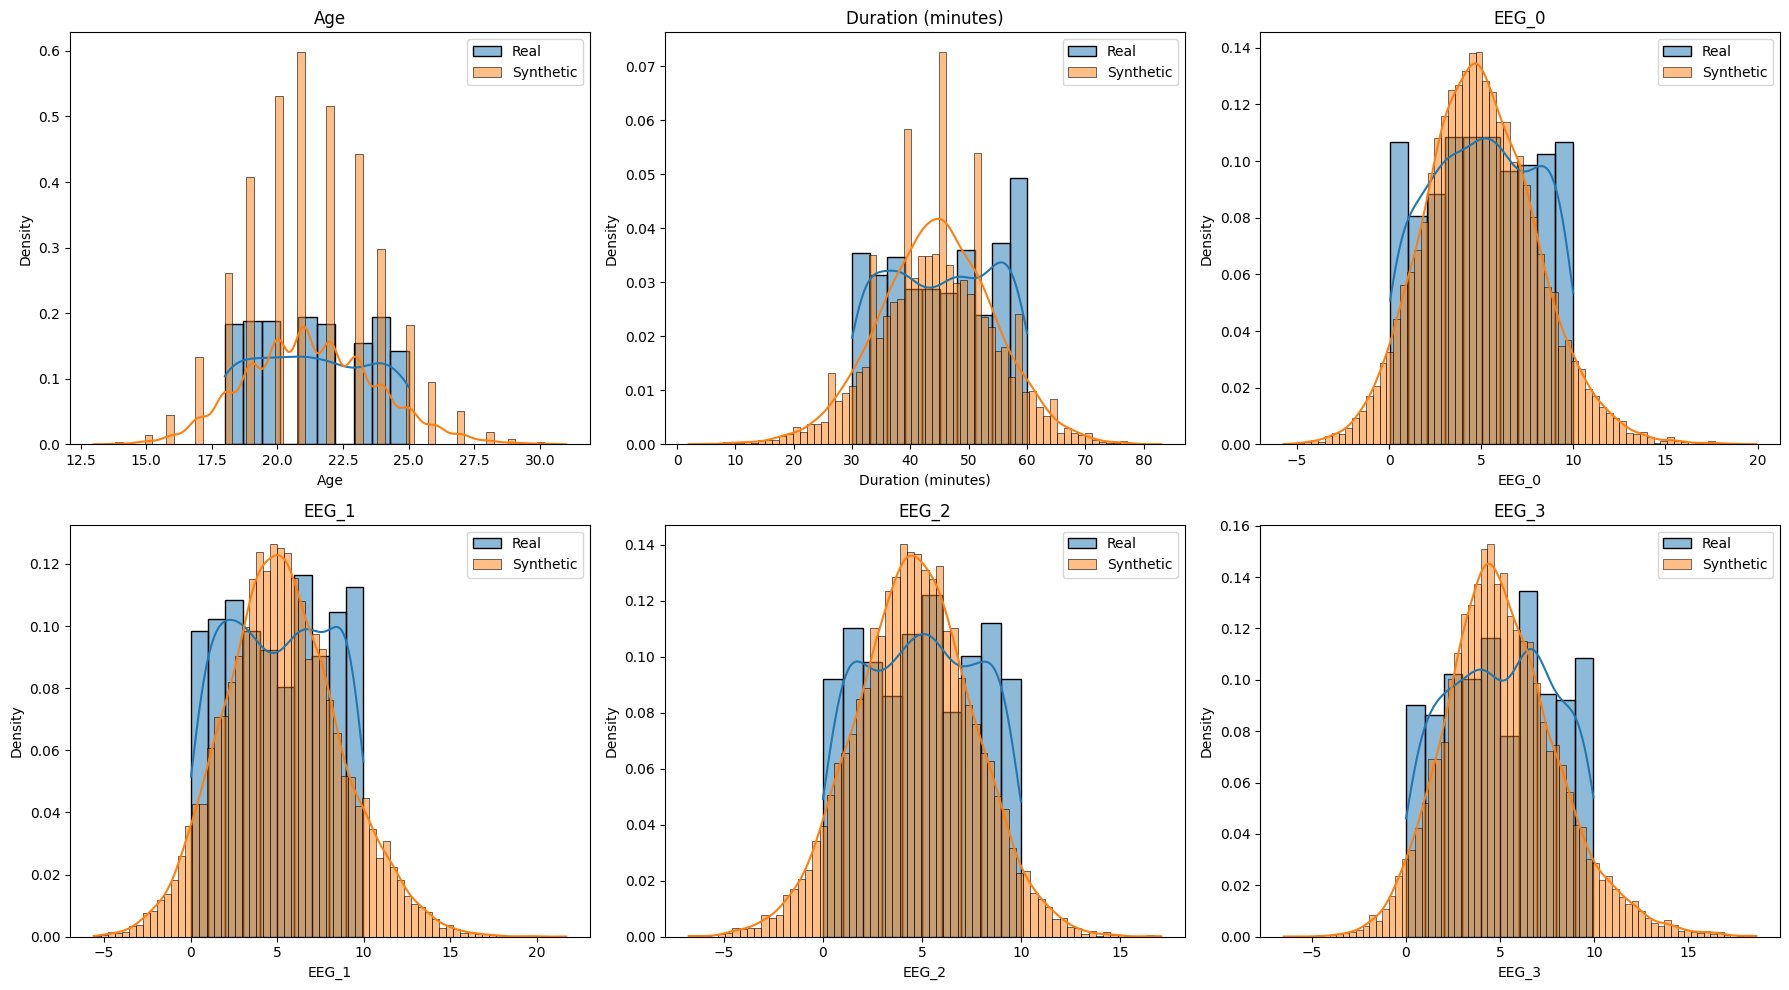

In [ ]:
selected_features = numeric_cols[:6]  # first 6 numeric columns

plt.figure(figsize=(18, 10))

for i, col in enumerate(selected_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(real_numeric[col].dropna(), kde=True, stat='density', label='Real', alpha=0.5)
    sns.histplot(synthetic_numeric[col].dropna(), kde=True, stat='density', label='Synthetic', alpha=0.5)
    plt.title(col)
    plt.legend()

plt.tight_layout()
plt.show()

13. KS test for numeric distributions

In [ ]:
ks_results = []

for col in numeric_cols:
    real_vals = real_numeric[col].dropna()
    syn_vals = synthetic_numeric[col].dropna()

    if len(real_vals) > 1 and len(syn_vals) > 1:
        ks_stat, p_value = ks_2samp(real_vals, syn_vals)
        ks_results.append([col, ks_stat, p_value])

ks_df = pd.DataFrame(ks_results, columns=['feature', 'ks_statistic', 'p_value'])
display(ks_df.sort_values('ks_statistic'))

,feature,ks_statistic,p_value
0,Age,0.0542,1.178990e-01
2,EEG_0,0.0747,9.371247e-03
5,EEG_3,0.0792,4.825902e-03
1,Duration (minutes),0.0842,2.205660e-03
8,Preprocessed_1,0.0853,1.844723e-03
3,EEG_1,0.0924,5.504329e-04
6,GSR_Values,0.0945,3.778187e-04
9,Timestamp,0.0951,3.387774e-04
4,EEG_2,0.0968,2.477802e-04
7,Preprocessed_0,0.1260,4.810719e-07


14. Correlation matrix comparison: preserving feature relationships.

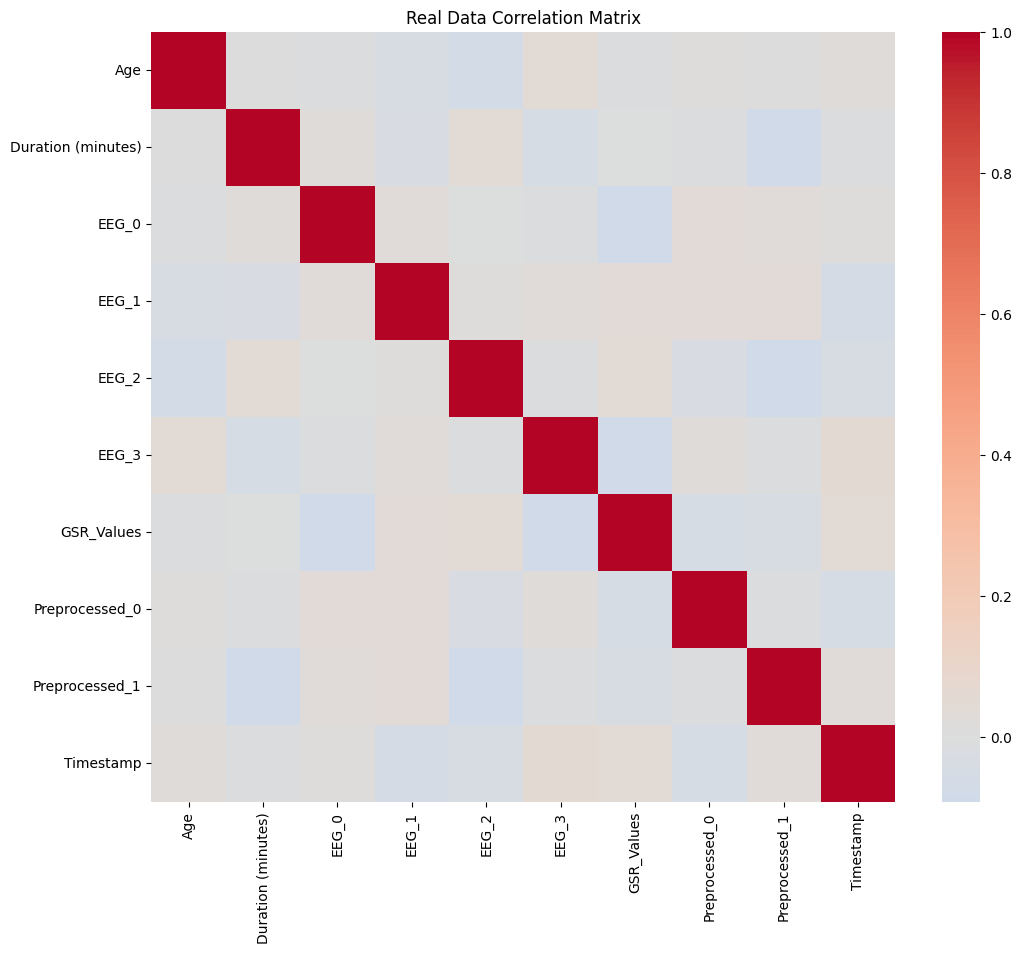

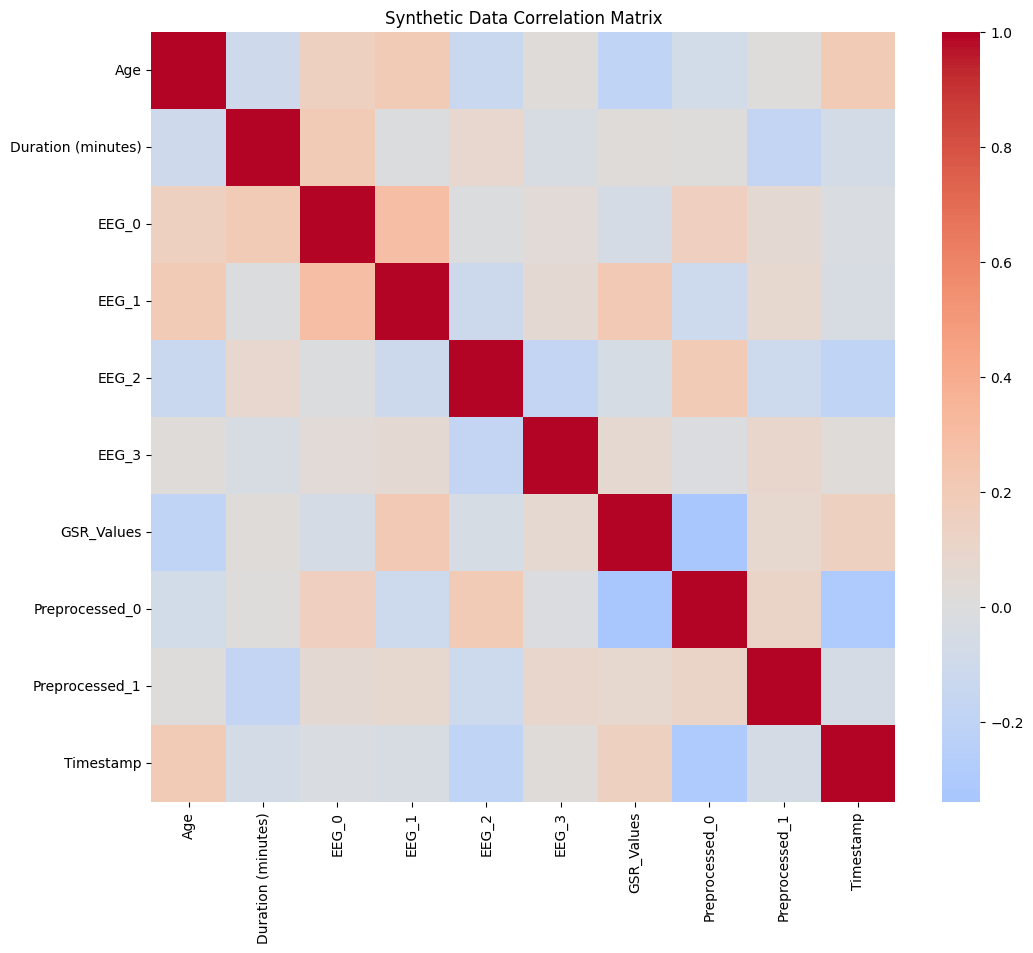

In [ ]:
real_corr = real_numeric.corr()
synthetic_corr = synthetic_numeric.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(real_corr, cmap='coolwarm', center=0)
plt.title("Real Data Correlation Matrix")
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(synthetic_corr, cmap='coolwarm', center=0)
plt.title("Synthetic Data Correlation Matrix")
plt.show()

15. Correlation difference summary

In [ ]:
corr_diff = (real_corr - synthetic_corr).abs()

print("Average absolute correlation difference:", corr_diff.mean().mean())
print("Maximum absolute correlation difference:", corr_diff.max().max())

display(corr_diff)

Average absolute correlation difference: 0.09155426146633536
Maximum absolute correlation difference: 0.2905271466106835


,Age,Duration (minutes),EEG_0,EEG_1,EEG_2,EEG_3,GSR_Values,Preprocessed_0,Preprocessed_1,Timestamp
Age,0.000000,0.109149,0.164753,0.238521,0.067243,0.022815,0.193472,0.095522,0.003255,0.179306
Duration (minutes),0.109149,0.000000,0.176681,0.019914,0.041773,0.003309,0.019724,0.023676,0.081076,0.066542
EEG_0,0.164753,0.176681,0.000000,0.266608,0.006425,0.048813,0.034972,0.126750,0.031443,0.034470
EEG_1,0.238521,0.019914,0.266608,0.000000,0.136625,0.029458,0.174994,0.149210,0.038167,0.020375
EEG_2,0.067243,0.041773,0.006425,0.136625,0.000000,0.161134,0.095341,0.230807,0.023603,0.153905
EEG_3,0.022815,0.003309,0.048813,0.029458,0.161134,0.000000,0.156847,0.042010,0.099268,0.028166
GSR_Values,0.193472,0.019724,0.034972,0.174994,0.095341,0.156847,0.000000,0.290527,0.113041,0.115278
Preprocessed_0,0.095522,0.023676,0.126750,0.149210,0.230807,0.042010,0.290527,0.000000,0.122503,0.250816
Preprocessed_1,0.003255,0.081076,0.031443,0.038167,0.023603,0.099268,0.113041,0.122503,0.000000,0.089426
Timestamp,0.179306,0.066542,0.034470,0.020375,0.153905,0.028166,0.115278,0.250816,0.089426,0.000000


16. Save correlation difference matrix

In [ ]:
corr_diff.to_csv("gan_correlation_difference_matrix.csv")
print("Saved: gan_correlation_difference_matrix.csv")

Saved: gan_correlation_difference_matrix.csv


17. Prepare data for PCA and t-SNE: only numeric columns and rows without missing values.

In [ ]:
real_clean = real_numeric.dropna().copy()
synthetic_clean = synthetic_numeric.dropna().copy()

# sample synthetic data to match real data size for fair visualization
synthetic_sampled = synthetic_clean.sample(n=min(len(real_clean), len(synthetic_clean)), random_state=42)

combined = pd.concat([real_clean, synthetic_sampled], axis=0)
labels = np.array(['Real'] * len(real_clean) + ['Synthetic'] * len(synthetic_sampled))

scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined)

print("Combined scaled shape:", combined_scaled.shape)

Combined scaled shape: (1000, 10)


18. PCA plot

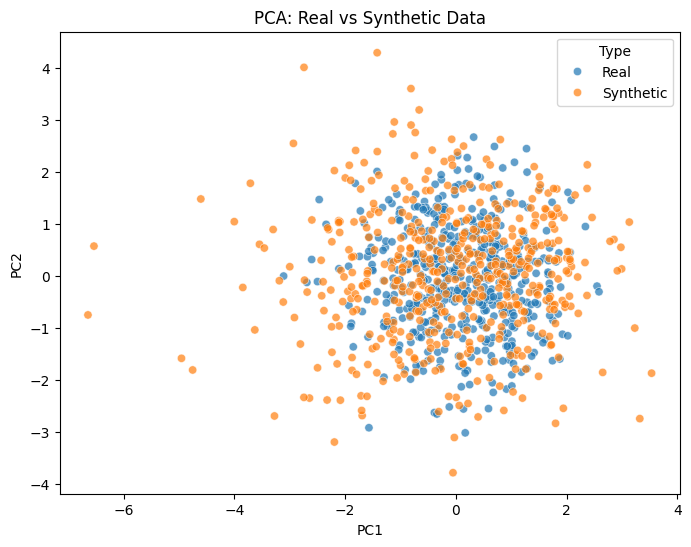

Explained variance ratio: [0.1586066  0.12785582]


In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(combined_scaled)

pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Type': labels
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Type', alpha=0.7)
plt.title("PCA: Real vs Synthetic Data")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

19. t-SNE plot

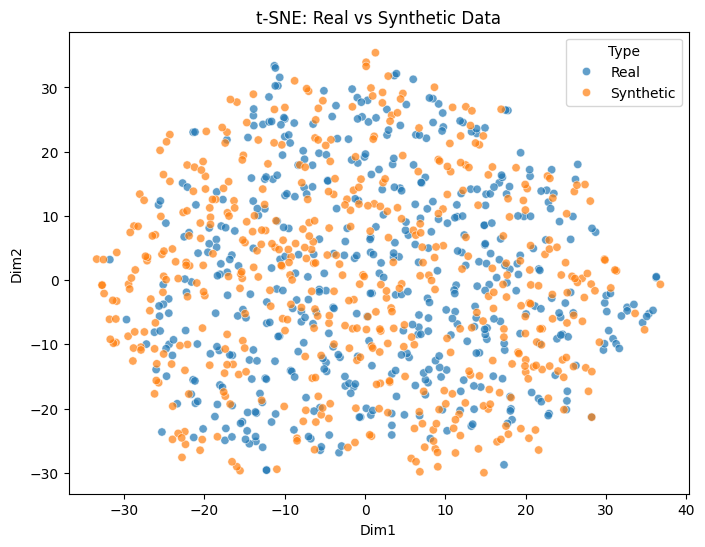

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(combined_scaled)

tsne_df = pd.DataFrame({
    'Dim1': tsne_result[:, 0],
    'Dim2': tsne_result[:, 1],
    'Type': labels
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2', hue='Type', alpha=0.7)
plt.title("t-SNE: Real vs Synthetic Data")
plt.show()

20. Compare categorical columns too

In [ ]:
for col in categorical_cols:
    print(f"\nColumn: {col}")

    print("Real:")
    display(real_common[col].astype(str).value_counts(dropna=False))

    print("Synthetic:")
    display(synthetic_common[col].astype(str).value_counts(dropna=False))


Column: Cognitive_State
Real:


,count
Cognitive_State,
Distracted,177
Cognitive Overload,164
Focused,159


Synthetic:


,count
Cognitive_State,
Distracted,5119
Cognitive Overload,2612
Focused,2269



Column: Emotional_State
Real:


...

,count
Gender,
Male,5582
Female,4418



Column: Session_Type
Real:


,count
Session_Type,
Test,174
Study,168
Relaxation,158


Synthetic:


,count
Session_Type,
Relaxation,3561
Test,3483
Study,2956


21. Save cleaned aligned datasets used in the validation

In [ ]:
real_common.to_csv("aligned_real_for_validation.csv", index=False)
synthetic_common.to_csv("aligned_synthetic_for_validation.csv", index=False)

print("Saved aligned datasets used in validation.")

Saved aligned datasets used in validation.
